In [36]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [37]:
x = iris.data
y = iris.target

In [38]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [29]:
df = pd.DataFrame(x, columns=iris.feature_names)
df['target'] = y
df['target_name'] = df['target'].map(lambda i: iris.target_names[i])

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [34]:
print(df.shape)
print(iris.target_names)

(150, 6)
['setosa' 'versicolor' 'virginica']


In [35]:
target_counts = df['target_name'].value_counts().sort_index()
target_counts

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

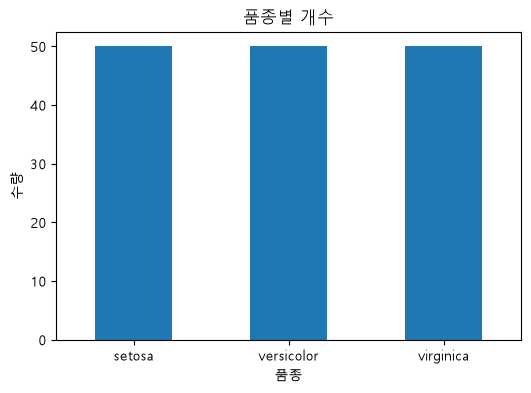

In [42]:
plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar')
plt.title('품종별 개수')
plt.xlabel('품종')
plt.ylabel('수량')
plt.xticks(rotation=0)
plt.show()

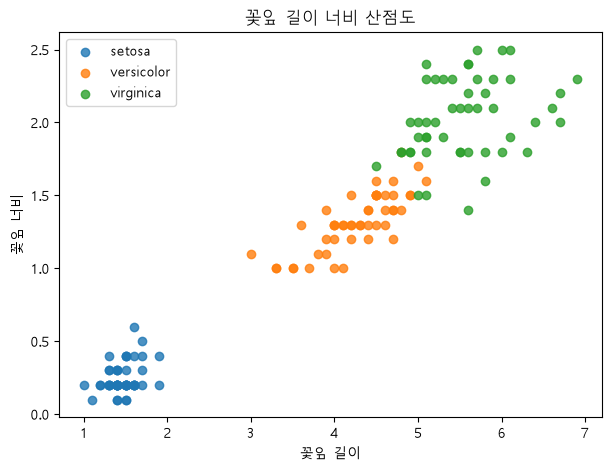

In [43]:
plt.figure(figsize=(7, 5))

for species in iris.target_names:
    subset = df[df['target_name'] == species]

    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=species,
        alpha=0.8
    )

plt.title('꽃잎 길이 너비 산점도')
plt.xlabel('꽃잎 길이')
plt.ylabel('꽃잎 너비')
plt.legend()
plt.show()

In [44]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [45]:
X = df[iris.feature_names]
y = df['target']

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [50]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
)

model.fit(X_train, y_train)
print("Model training Complete")

Model training Complete


In [54]:
y_pred = model.predict(X_test)

y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

In [60]:
accuracy = accuracy_score(y_test, y_pred)

print(f'정확도: {accuracy:0.2f}')

정확도: 0.97


In [62]:
report = classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names,
    output_dict=True
)

pd.DataFrame(report).T

,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,10.000000
versicolor,1.000000,0.900000,0.947368,10.000000
virginica,0.909091,1.000000,0.952381,10.000000
accuracy,0.966667,0.966667,0.966667,0.966667
macro avg,0.969697,0.966667,0.966583,30.000000
weighted avg,0.969697,0.966667,0.966583,30.000000


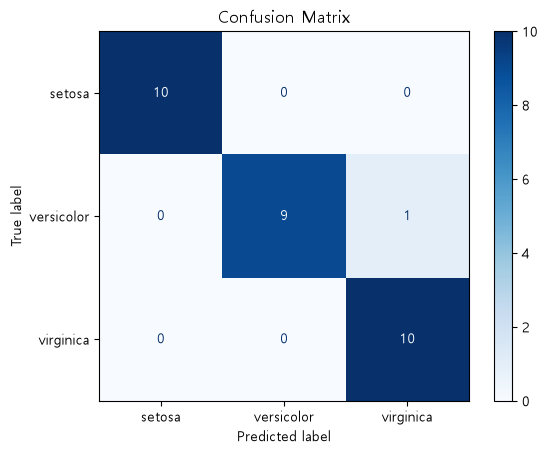

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.show()

In [66]:
sample = pd.DataFrame(
    [[5.1, 3.0, 1.4, 1.0]],
    columns=iris.feature_names
)

sample

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.0,1.4,1.0


In [71]:
pred = model.predict(sample)
pred_name = iris.target_names[pred[0]]
pred_name

np.str_('setosa')

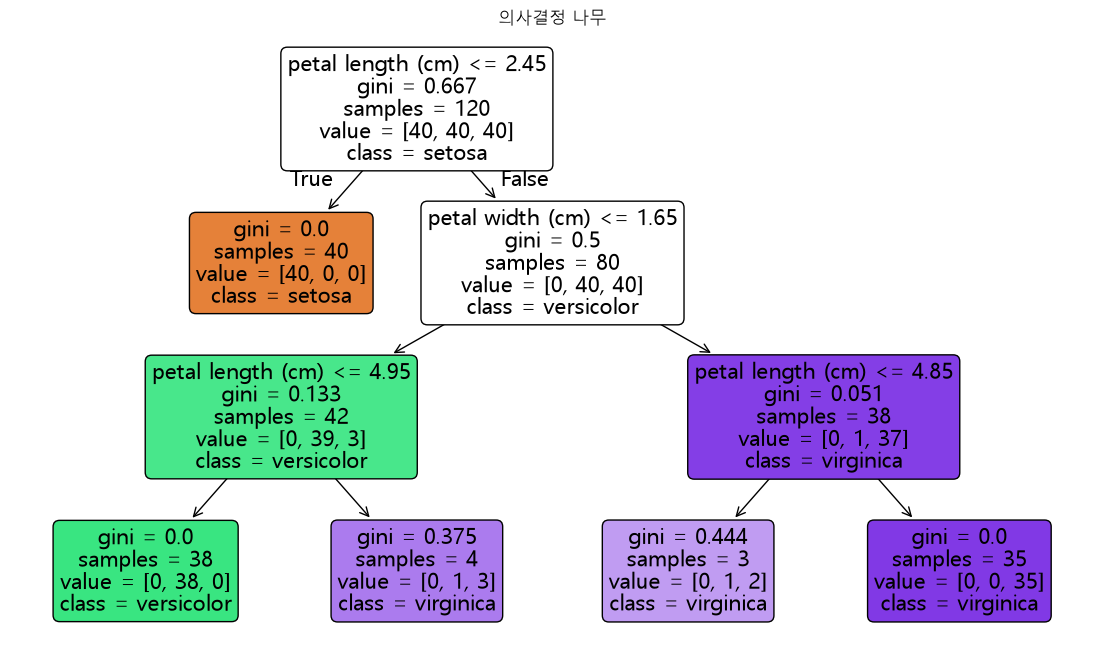

In [73]:
plt.figure(figsize=(14, 8))

plot_tree(
    model, 
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title('의사결정 나무')
plt.show()

In [75]:
model.feature_importances_

array([0.        , 0.        , 0.57907728, 0.42092272])

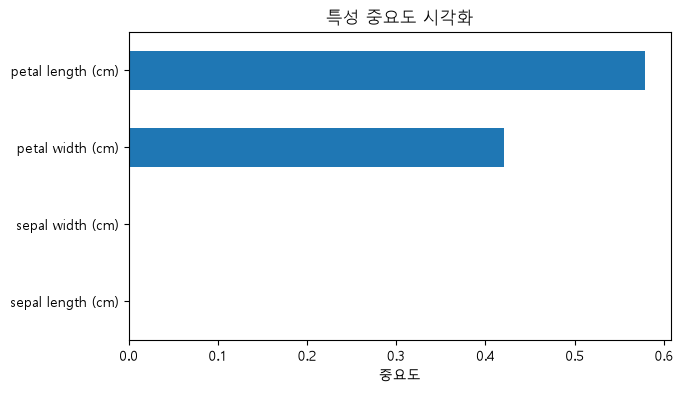

In [76]:
importance = pd.Series(
    model.feature_importances_,
    index=iris.feature_names
).sort_values()

plt.figure(figsize=(7, 4))
importance.plot(kind='barh')
plt.title('특성 중요도 시각화')
plt.xlabel('중요도')
plt.show()

머신러닝 순서
1. 데이터 준비
2. 데이터 전처리
3. 입력 데이터 x, 정답 데이터 y 분리
4. 학습용 데이터와 테스트용 데이터 분리
5. 모델 생성
6. 모델 학습: fit()
7. 테스트 데이터로 검증
8. predict() 예측
9. 모델 정확도 시각화